In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

C:\Users\mirna\anaconda3\envs\network_env\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [19]:
fs_results = pd.read_csv('results/Texas_feature_selection_results.csv')
fs_results

,Dataset,Cohort Size,Num Features,Method,Feature Name,Score
0,Complete Cohort,62449,754,Variance Threshold,pcd,1.000000
1,Complete Cohort,62449,754,Variance Threshold,Submitted_HIPPS_Code_1AHKS,1.000000
2,Complete Cohort,62449,754,Variance Threshold,Primary_Diagnosis_ICD_10_C_M_Code_Cluster_G2_O...,1.000000
3,Complete Cohort,62449,754,Variance Threshold,Submitted_HIPPS_Code_1CHKU,1.000000
4,Complete Cohort,62449,754,Variance Threshold,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster_G1_21,1.000000
...,...,...,...,...,...,...
24123,Hypertensive Patients,16161,754,HIR-M3 Attention Importance,COUNTY_NAME_McLennan,0.114419
24124,Hypertensive Patients,16161,754,HIR-M3 Attention Importance,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster_G2_11_1,0.103787
24125,Hypertensive Patients,16161,754,HIR-M3 Attention Importance,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster_G1_26,0.102432
24126,Hypertensive Patients,16161,754,HIR-M3 Attention Importance,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster_Other,0.099027


In [20]:
datasets = fs_results["Dataset"].unique()
methods = fs_results["Method"].unique()
print(datasets)
print(methods)

<ArrowStringArray>
[       'Complete Cohort',      'Diabetic Patients', 'Heart Failure Patients',
  'Hypertensive Patients']
Length: 4, dtype: str
<ArrowStringArray>
[                   'Variance Threshold',
                     'Lasso (L1 LogReg)',
              'Random Forest Importance',
           'Permutation Importance (RF)',
 'Permutation Importance (Ridge/LogReg)',
                   'LightGBM Importance',
                    'XGBoost Importance',
           'HIR-M3 Attention Importance']
Length: 8, dtype: str


In [28]:
score_methods = [
    "Variance Threshold",
    "Lasso (L1 LogReg)",
    "Random Forest Importance",
    "Permutation Importance (RF)",
    "Permutation Importance (Ridge/LogReg)",
    "LightGBM Importance",
    "XGBoost Importance",
    "HIR-M3 Attention Importance",
]
method_name_map = {
    "Lasso L1 LogReg": "Lasso (L1 LogReg)",
    "Random Forest Gini": "Random Forest Importance",
    "Permutation Importance RF": "Permutation Importance (RF)",
    "Permutation Importance RidgeLogReg": "Permutation Importance (Ridge/LogReg)",
}

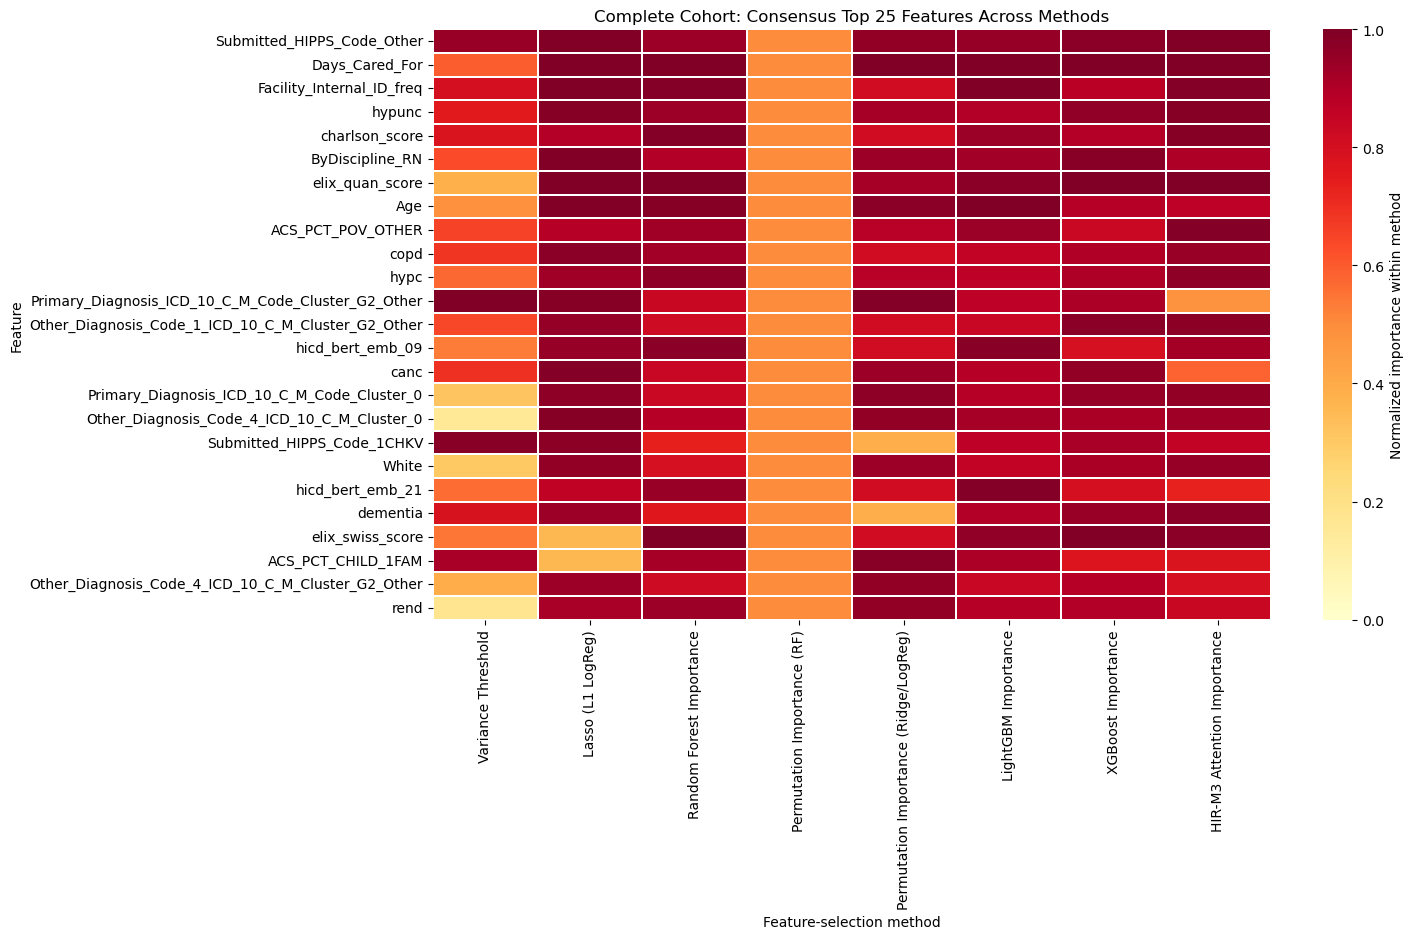

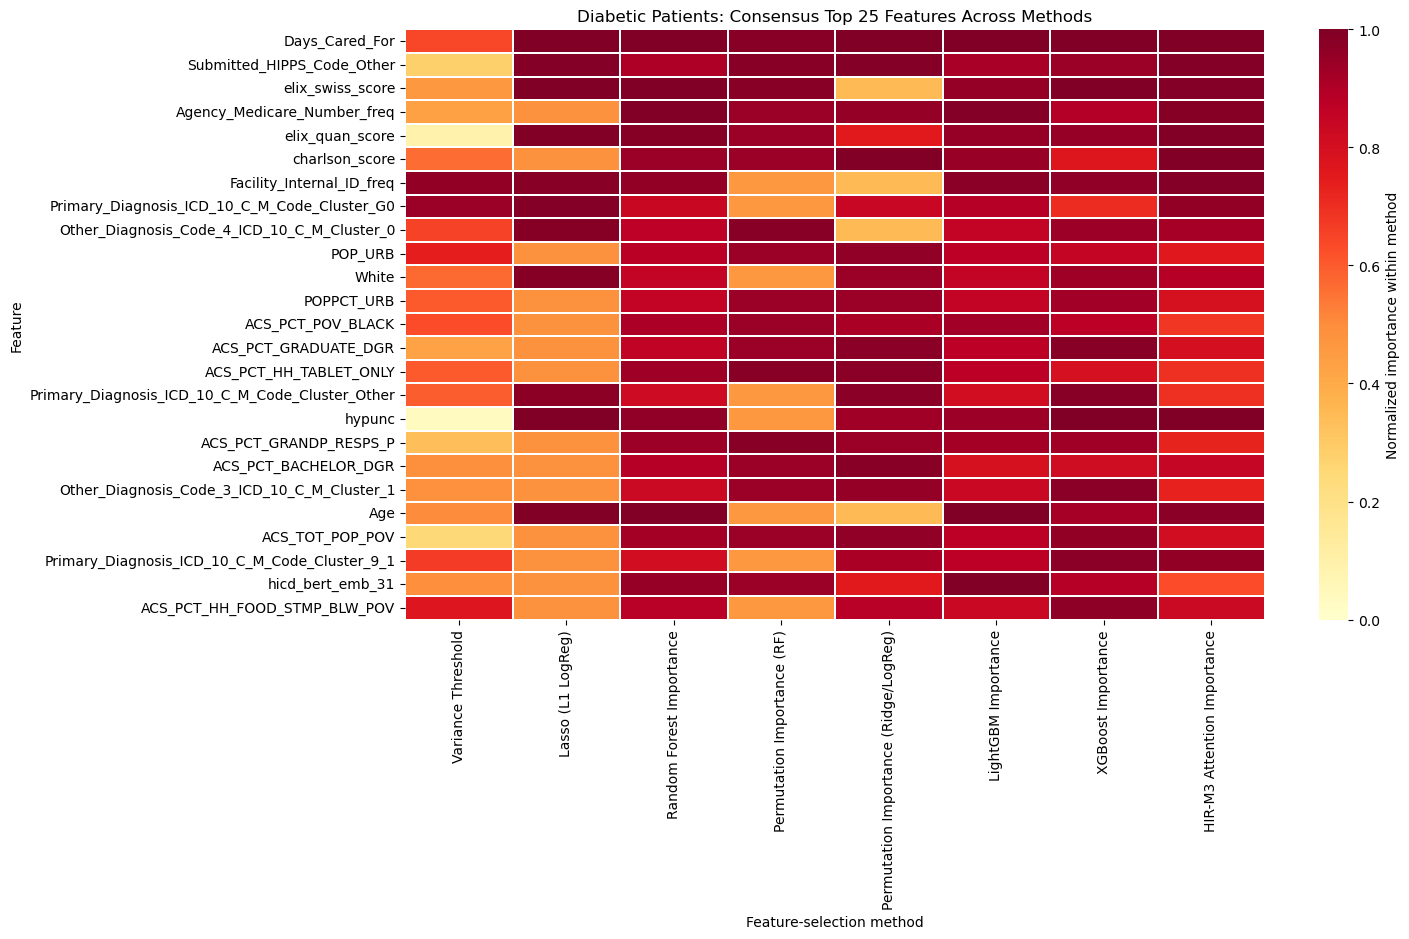

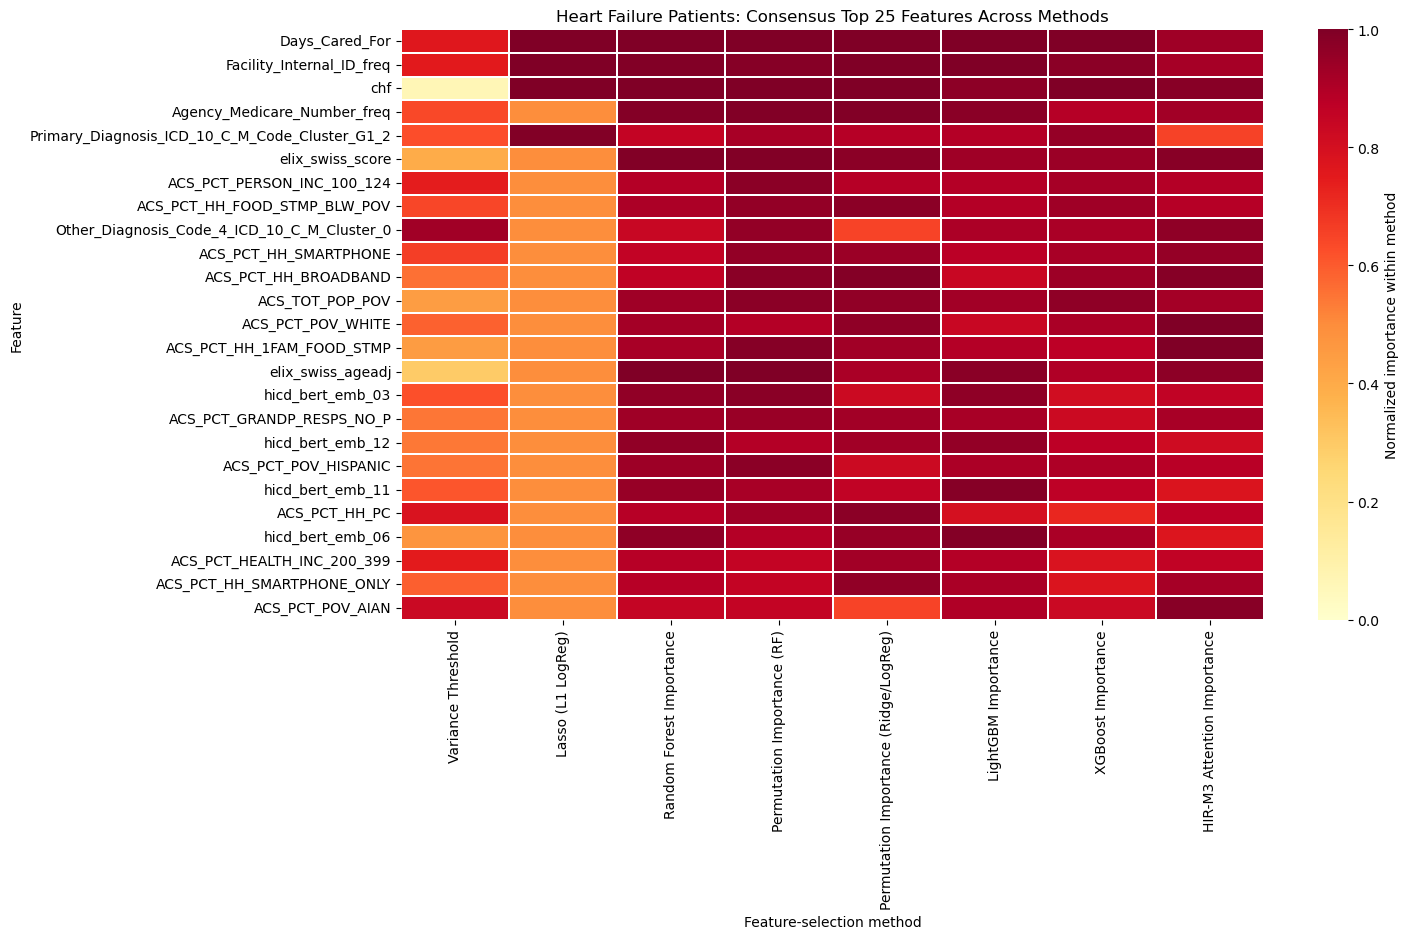

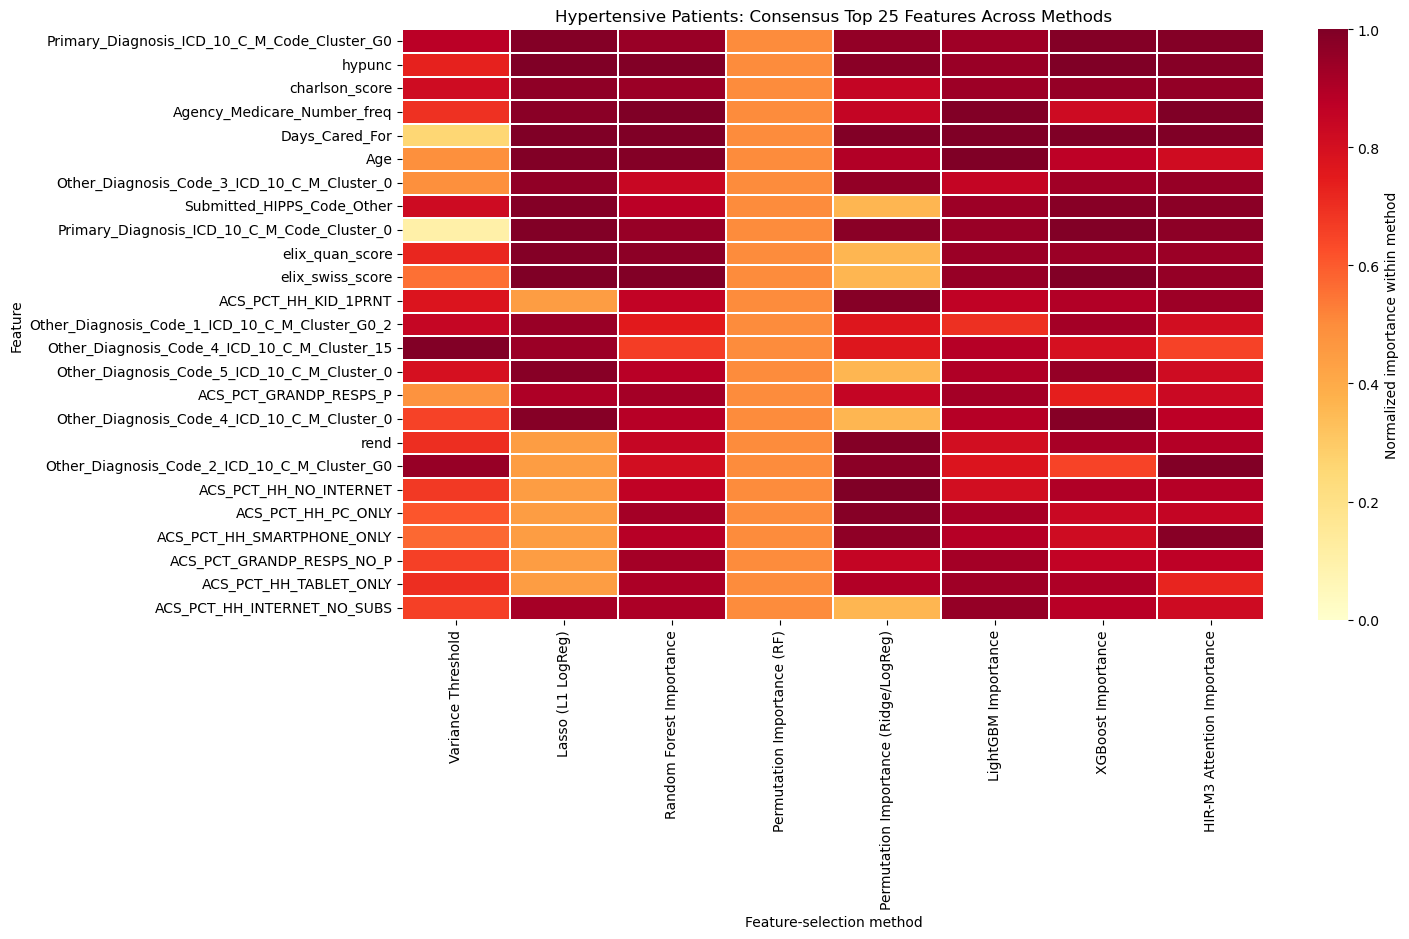

In [30]:
TOP_N_CONSENSUS = 25

for dataset in sorted(fs_plot["Dataset"].unique()):

    dataset_df = fs_plot.loc[
        fs_plot["Dataset"].eq(dataset)
    ].copy()

    # Average normalized importance across available methods.
    consensus = (
        dataset_df.groupby("Feature Name", as_index=False)
        .agg(
            MeanNormalizedImportance=(
                "NormalizedImportance", "mean"
            ),
            MethodsReported=("Method", "nunique")
        )
        .sort_values(
            "MeanNormalizedImportance",
            ascending=False
        )
    )

    top_features = consensus.head(TOP_N_CONSENSUS)["Feature Name"].tolist()

    heatmap_df = dataset_df.loc[
        dataset_df["Feature Name"].isin(top_features)
    ].pivot_table(
        index="Feature Name",
        columns="Method",
        values="NormalizedImportance",
        aggfunc="mean",
        fill_value=0
    )

    # Retain requested method order where a method is available.
    method_order = [
        method for method in score_methods
        if method in heatmap_df.columns
    ]

    heatmap_df = heatmap_df.reindex(columns=method_order)

    feature_order = (
        consensus.loc[
            consensus["Feature Name"].isin(top_features)
        ]
        .sort_values(
            "MeanNormalizedImportance",
            ascending=False
        )["Feature Name"]
        .tolist()
    )

    heatmap_df = heatmap_df.reindex(feature_order)

    fig_height = max(7, 0.38 * len(heatmap_df))

    fig, ax = plt.subplots(figsize=(15, fig_height))

    sns.heatmap(
        heatmap_df,
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
        linewidths=0.35,
        linecolor="white",
        cbar_kws={
            "label": "Normalized importance within method"
        },
        ax=ax
    )

    ax.set_title(
        f"{dataset}: Consensus Top {TOP_N_CONSENSUS} Features Across Methods"
    )
    ax.set_xlabel("Feature-selection method")
    ax.set_ylabel("Feature")

    fig.tight_layout()

    dataset_file = (
        str(dataset)
        .replace(" ", "_")
        .replace("/", "_")
    )

    fig.savefig(
        f"figs/{dataset_file}_feature_importance_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

In [14]:
fs_results_nw = pd.read_csv('results/Nationwide_feature_selection_results.csv')
fs_results_nw

,Dataset,Cohort Size,Num Features,Method,Feature Name,Score
0,Complete Cohort,2864697,2566,Variance Threshold,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster_93,1.000000
1,Complete Cohort,2864697,2566,Variance Threshold,COUNTY_NAME_Laramie,1.000000
2,Complete Cohort,2864697,2566,Variance Threshold,COUNTY_NAME_Mayes,1.000000
3,Complete Cohort,2864697,2566,Variance Threshold,COUNTY_NAME_Galveston,1.000000
4,Complete Cohort,2864697,2566,Variance Threshold,COUNTY_NAME_Greene,1.000000
...,...,...,...,...,...,...
79541,Hypertensive Patients,579643,2566,HIR-M3 Attention Importance,Primary_Diagnosis_ICD_10_C_M_Code_Cluster_12,0.000054
79542,Hypertensive Patients,579643,2566,HIR-M3 Attention Importance,COUNTY_NAME_Camp,0.000051
79543,Hypertensive Patients,579643,2566,HIR-M3 Attention Importance,Primary_Diagnosis_ICD_10_C_M_Code_Cluster_560,0.000021
79544,Hypertensive Patients,579643,2566,HIR-M3 Attention Importance,COUNTY_NAME_Neshoba,0.000008
